
# Triadic Cell Notebook v22
## Runtime defrag: Shape / Bridge / Value separation

This notebook implements the next practical correction.

The problem is not that the runtime law failed.
The problem is that the channels were mixed.

The new rule is:

- **Shape** = inside reading
- **Bridge** = action law
- **Value** = outside readout

And the lift is:

$$
\text{one layer's shape is the next layer's value}
$$

but only **through** the bridge operator.

## What this notebook does

1. Builds a synthetic packet world with:
   - left rail
   - hinge
   - right rail
   - carry

2. Creates **shape traces** under multiple corruption modes:
   - clean
   - missing left rail
   - missing right rail
   - bad carry
   - ambiguous
   - noisy
   - broken

3. Defrags the trace set:
   - clusters near-identical shape packets
   - makes canonical packet prototypes
   - keeps action labels separate from final readout labels

4. Trains a tiny **policy head** to predict:
   - promote
   - hold
   - retire
   - grow_left
   - grow_right
   - grow_carry

5. Compares:
   - raw-trace policy head
   - defragged policy head

This is the first notebook in the line where the learned model is asked to predict **search action**, not final class label.



## Practical answer

For the current build, the likely missing step is indeed a **defrag** —
but a defrag of roles, not bytes.

So the practical architecture is now:

- **Shape bus**
  - support
  - hinge
  - carry
  - contradiction
  - route margin

- **Bridge bus**
  - promote
  - hold
  - retire
  - grow missing support

- **Value bus**
  - label
  - decoded answer
  - report

The learned head belongs in the **Bridge** layer.


In [1]:

from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
np.set_printoptions(suppress=True, precision=4)

rng = np.random.default_rng(42)

print("Environment ready.")


Environment ready.



## Canonical packet world

Each class has:
- a local value identity (`prefix`)
- a tail prototype (`shape witness`)

We also define action labels for the bridge layer.


In [2]:

prefixes = np.array([
    [1.00, 0.05, 0.05, 0.05],
    [0.05, 1.00, 0.05, 0.05],
    [0.05, 0.05, 1.00, 0.05],
    [0.05, 0.05, 0.05, 1.00],
], dtype=float)

tail_prototypes = np.array([
    [0.92, 0.18, 0.58, 0.22],
    [0.18, 0.90, 0.26, 0.60],
    [0.62, 0.24, 0.90, 0.18],
    [0.22, 0.62, 0.18, 0.88],
], dtype=float)

ACTION_NAMES = ["promote", "hold", "retire", "grow_left", "grow_right", "grow_carry"]
ACTION_TO_ID = {name: i for i, name in enumerate(ACTION_NAMES)}
ID_TO_ACTION = {i: name for name, i in ACTION_TO_ID.items()}

def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    na = np.linalg.norm(a) + 1e-8
    nb = np.linalg.norm(b) + 1e-8
    return float(np.dot(a, b) / (na * nb))

def top2_margin(scores: np.ndarray):
    order = np.argsort(scores)[::-1]
    top1_idx = int(order[0])
    top1 = float(scores[order[0]])
    top2 = float(scores[order[1]]) if len(order) > 1 else 0.0
    return top1_idx, top1, top1 - top2



## Corruption modes

These are the things the bridge should learn to respond to.
Not all damaged inputs should be retired.
Some should be repaired.


In [3]:

CORRUPTION_MODES = [
    "clean",
    "missing_left",
    "missing_right",
    "bad_carry",
    "ambiguous",
    "noisy",
    "broken",
]

corruption_weights = np.array([0.22, 0.14, 0.14, 0.16, 0.12, 0.14, 0.08], dtype=float)
corruption_weights = corruption_weights / corruption_weights.sum()

def corrupt_tail(base_tail: np.ndarray, mode: str) -> np.ndarray:
    x = base_tail.copy()

    if mode == "clean":
        x += rng.normal(0.0, 0.02, size=x.shape[0])

    elif mode == "missing_left":
        x[0] *= rng.uniform(0.0, 0.20)
        x += rng.normal(0.0, 0.02, size=x.shape[0])

    elif mode == "missing_right":
        x[3] *= rng.uniform(0.0, 0.20)
        x += rng.normal(0.0, 0.02, size=x.shape[0])

    elif mode == "bad_carry":
        x[1] = np.clip(x[1] + rng.uniform(0.35, 0.55), 0.0, 1.0)
        x[2] = np.clip(x[2] - rng.uniform(0.20, 0.35), 0.0, 1.0)
        x += rng.normal(0.0, 0.02, size=x.shape[0])

    elif mode == "ambiguous":
        alt = int((np.argmax(base_tail) + 1) % len(tail_prototypes))
        blend = 0.45 * tail_prototypes[alt] + 0.55 * base_tail
        x = blend + rng.normal(0.0, 0.02, size=x.shape[0])

    elif mode == "noisy":
        mask = rng.random(x.shape[0]) < 0.25
        x[mask] = 0.0
        x += rng.normal(0.0, 0.05, size=x.shape[0])

    elif mode == "broken":
        x = rng.uniform(0.0, 1.0, size=x.shape[0])

    return np.clip(x, 0.0, 1.0)



## Shape packet extraction

This is the shape bus.
No final label appears here.

The bridge acts on:
- left support
- hinge fit
- right support
- carry fit
- contradiction
- route margin


In [4]:

def packet_shape_features(observed_tail: np.ndarray, candidate_slot: int):
    candidate_tail = tail_prototypes[candidate_slot]
    candidate_prefix = prefixes[candidate_slot]

    left_support = 1.0 - abs(observed_tail[0] - candidate_tail[0])
    hinge_fit = 1.0 - abs(observed_tail[2] - candidate_tail[2])
    right_support = 1.0 - abs(observed_tail[3] - candidate_tail[3])

    carry_target = 0.5 * candidate_tail[1] + 0.5 * candidate_tail[2]
    carry_obs = 0.5 * observed_tail[1] + 0.5 * observed_tail[2]
    carry_fit = 1.0 - abs(carry_obs - carry_target)

    tail_fit = cosine_similarity(observed_tail, candidate_tail)
    prefix_hint = cosine_similarity(observed_tail, candidate_prefix)
    contradiction = 1.0 - prefix_hint
    bilateral = 0.5 * (left_support + right_support)
    support_balance = 1.0 - abs(left_support - right_support)

    return {
        "left_support": float(np.clip(left_support, 0.0, 1.0)),
        "hinge_fit": float(np.clip(hinge_fit, 0.0, 1.0)),
        "right_support": float(np.clip(right_support, 0.0, 1.0)),
        "carry_fit": float(np.clip(carry_fit, 0.0, 1.0)),
        "tail_fit": float(np.clip(tail_fit, 0.0, 1.0)),
        "prefix_hint": float(np.clip(prefix_hint, 0.0, 1.0)),
        "contradiction": float(np.clip(contradiction, 0.0, 1.0)),
        "bilateral": float(np.clip(bilateral, 0.0, 1.0)),
        "support_balance": float(np.clip(support_balance, 0.0, 1.0)),
    }

def value_only_predict(observed_tail: np.ndarray):
    scores = np.array([cosine_similarity(observed_tail, t) for t in tail_prototypes], dtype=float)
    pred_slot, _, margin = top2_margin(scores)
    return pred_slot, float(margin), scores

def packet_gate(shape_features: dict, route_margin: float):
    gate_score = (
        0.18 * shape_features["left_support"]
        + 0.22 * shape_features["hinge_fit"]
        + 0.18 * shape_features["right_support"]
        + 0.14 * shape_features["carry_fit"]
        + 0.12 * shape_features["tail_fit"]
        + 0.10 * shape_features["bilateral"]
        + 0.06 * route_margin
    )
    passes = (
        shape_features["left_support"] > 0.58 and
        shape_features["hinge_fit"] > 0.58 and
        shape_features["right_support"] > 0.58 and
        shape_features["carry_fit"] > 0.54 and
        route_margin > 0.03 and
        gate_score > 0.62
    )
    return float(gate_score), bool(passes)



## Bridge oracle

The bridge does not predict class.
It predicts **what the search should do next**.


In [5]:

def bridge_oracle(pred_slot: int, target_slot: int, shape_features: dict, route_margin: float):
    gate_score, passes = packet_gate(shape_features, route_margin)

    if pred_slot != target_slot and shape_features["tail_fit"] < 0.82:
        return "retire", gate_score, passes

    if shape_features["left_support"] < 0.54 and shape_features["right_support"] >= 0.58:
        return "grow_left", gate_score, passes

    if shape_features["right_support"] < 0.54 and shape_features["left_support"] >= 0.58:
        return "grow_right", gate_score, passes

    if shape_features["carry_fit"] < 0.54:
        return "grow_carry", gate_score, passes

    if shape_features["hinge_fit"] < 0.56 or route_margin < 0.04 or gate_score < 0.60:
        return "hold", gate_score, passes

    if passes and pred_slot == target_slot:
        return "promote", gate_score, passes

    return "hold", gate_score, passes



## Generate raw traces

Each row is now a true bridge-training example:
- observed tail
- best candidate slot
- shape packet
- bridge action target
- value readout correctness (for evaluation only)


In [6]:

rows = []
n_per_class = 800

for target_slot in range(4):
    base_tail = tail_prototypes[target_slot]
    for _ in range(n_per_class):
        mode = rng.choice(CORRUPTION_MODES, p=corruption_weights)
        observed_tail = corrupt_tail(base_tail, mode)

        pred_slot, value_margin, value_scores = value_only_predict(observed_tail)
        shape = packet_shape_features(observed_tail, pred_slot)
        action, gate_score, packet_pass = bridge_oracle(pred_slot, target_slot, shape, value_margin)

        row = {
            "target_slot": target_slot,
            "pred_slot": pred_slot,
            "corruption_mode": mode,
            "value_margin": value_margin,
            "gate_score": gate_score,
            "packet_pass": int(packet_pass),
            "action": action,
            "action_id": ACTION_TO_ID[action],
            "value_correct": int(pred_slot == target_slot),
        }

        for k, v in shape.items():
            row[k] = v

        for i, v in enumerate(observed_tail):
            row[f"tail_{i}"] = float(v)

        rows.append(row)

trace_df = pd.DataFrame(rows)
trace_df.head()


,target_slot,pred_slot,corruption_mode,value_margin,gate_score,packet_pass,action,action_id,value_correct,left_support,...,carry_fit,tail_fit,prefix_hint,contradiction,bilateral,support_balance,tail_0,tail_1,tail_2,tail_3
0,0,0,ambiguous,0.013878,0.772904,0,hold,1,1,0.646200,...,0.893090,0.885914,0.656709,0.343291,0.757111,0.778180,0.566200,0.519009,0.454811,0.351979
1,0,1,broken,0.045257,0.711130,0,grow_left,3,0,0.418860,...,0.877089,0.855923,0.714074,0.285926,0.634623,0.568474,0.761140,0.786064,0.128114,0.450386
2,0,0,missing_right,0.068752,0.892485,1,promote,0,1,0.998679,...,0.984052,0.984392,0.861548,0.138452,0.901136,0.804912,0.921321,0.202545,0.589350,0.023592
3,0,0,bad_carry,0.145746,0.855480,1,promote,0,1,0.999001,...,0.989349,0.903228,0.863377,0.136623,0.987275,0.976548,0.919001,0.539066,0.242237,0.244451
4,0,0,noisy,0.054094,0.856909,1,promote,0,1,0.979363,...,0.974312,0.968035,0.834666,0.165334,0.879682,0.800637,0.940637,0.021541,0.687082,0.000000



## Raw trace summary


In [7]:

raw_summary = pd.DataFrame([{
    "value_only_accuracy": float(trace_df["value_correct"].mean()),
    "packet_pass_rate": float(trace_df["packet_pass"].mean()),
    "mean_gate_score": float(trace_df["gate_score"].mean()),
}])

action_mix = (
    trace_df["action"]
    .value_counts(normalize=True)
    .rename_axis("action")
    .reset_index(name="fraction")
)

raw_summary, action_mix


(   value_only_accuracy  packet_pass_rate  mean_gate_score
 0             0.799375          0.674063         0.841044,
        action  fraction
 0     promote  0.593437
 1        hold  0.210938
 2   grow_left  0.094375
 3  grow_right  0.087188
 4      retire  0.013437
 5  grow_carry  0.000625)


## Defrag pass

This is the key new move.

We cluster near-identical shape packets **within the same action class** and replace them with canonical prototypes.
That removes duplicated local fragments and gives the bridge head cleaner objects to learn from.


In [8]:

shape_cols = [
    "left_support",
    "hinge_fit",
    "right_support",
    "carry_fit",
    "tail_fit",
    "prefix_hint",
    "contradiction",
    "bilateral",
    "support_balance",
    "value_margin",
    "gate_score",
]

def greedy_defrag(df: pd.DataFrame, similarity_threshold: float = 0.992):
    canonical_rows = []

    for action in ACTION_NAMES:
        sub = df[df["action"] == action].reset_index(drop=True)
        if len(sub) == 0:
            continue

        X = sub[shape_cols].to_numpy(dtype=float)
        norms = np.linalg.norm(X, axis=1, keepdims=True) + 1e-8
        Xn = X / norms

        clusters = []

        for i in range(len(sub)):
            x = Xn[i]
            assigned = False

            for cluster in clusters:
                sim = float(np.dot(x, cluster["prototype"]))
                if sim >= similarity_threshold:
                    cluster["members"].append(i)
                    member_idx = cluster["members"]
                    mean_vec = Xn[member_idx].mean(axis=0)
                    cluster["prototype"] = mean_vec / (np.linalg.norm(mean_vec) + 1e-8)
                    assigned = True
                    break

            if not assigned:
                clusters.append({
                    "prototype": x.copy(),
                    "members": [i],
                })

        for cid, cluster in enumerate(clusters):
            member_df = sub.iloc[cluster["members"]]
            row = {col: float(member_df[col].mean()) for col in shape_cols}
            row["action"] = action
            row["action_id"] = ACTION_TO_ID[action]
            row["weight"] = int(len(member_df))
            row["cluster_id"] = cid
            canonical_rows.append(row)

    return pd.DataFrame(canonical_rows)

defrag_df = greedy_defrag(trace_df, similarity_threshold=0.992)
defrag_summary = pd.DataFrame([{
    "raw_packets": int(len(trace_df)),
    "canonical_packets": int(len(defrag_df)),
    "compression_ratio": float(len(defrag_df) / len(trace_df)),
    "mean_cluster_weight": float(defrag_df["weight"].mean()),
}])

defrag_summary


,raw_packets,canonical_packets,compression_ratio,mean_cluster_weight
0,3200,70,0.021875,45.714286



## Train tiny policy heads

Both heads use **shape only**.

- raw head: trained on raw traces
- defrag head: trained on canonical packets with weights


In [9]:

def softmax(z):
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

def one_hot(y, k):
    out = np.zeros((len(y), k), dtype=float)
    out[np.arange(len(y)), y] = 1.0
    return out

def standardize_train_test(X_train, X_test):
    mu = X_train.mean(axis=0, keepdims=True)
    sd = X_train.std(axis=0, keepdims=True) + 1e-8
    return (X_train - mu) / sd, (X_test - mu) / sd, mu, sd

def train_multiclass_logreg(X, y, sample_weight=None, lr=0.08, epochs=800):
    n_samples, n_features = X.shape
    n_classes = int(np.max(y)) + 1

    W = np.zeros((n_features, n_classes), dtype=float)
    b = np.zeros((1, n_classes), dtype=float)

    Y = one_hot(y, n_classes)
    if sample_weight is None:
        sample_weight = np.ones(n_samples, dtype=float)
    sample_weight = sample_weight.reshape(-1, 1)
    weight_scale = sample_weight / (sample_weight.sum() + 1e-8)

    loss_history = []

    for _ in range(epochs):
        logits = X @ W + b
        probs = softmax(logits)

        loss = -np.sum(weight_scale * np.sum(Y * np.log(probs + 1e-8), axis=1, keepdims=True))
        loss_history.append(float(loss))

        dlogits = (probs - Y) * weight_scale
        dW = X.T @ dlogits
        db = dlogits.sum(axis=0, keepdims=True)

        W -= lr * dW
        b -= lr * db

    return W, b, loss_history

def predict_logreg(X, W, b):
    probs = softmax(X @ W + b)
    return probs.argmax(axis=1), probs


In [10]:

perm = rng.permutation(len(trace_df))
split = int(0.8 * len(trace_df))
train_idx = perm[:split]
test_idx = perm[split:]

raw_train = trace_df.iloc[train_idx].reset_index(drop=True)
raw_test = trace_df.iloc[test_idx].reset_index(drop=True)

X_train_raw = raw_train[shape_cols].to_numpy(dtype=float)
y_train_raw = raw_train["action_id"].to_numpy(dtype=int)
X_test = raw_test[shape_cols].to_numpy(dtype=float)
y_test = raw_test["action_id"].to_numpy(dtype=int)

X_train_raw_s, X_test_s, raw_mu, raw_sd = standardize_train_test(X_train_raw, X_test)
W_raw, b_raw, raw_loss = train_multiclass_logreg(X_train_raw_s, y_train_raw, sample_weight=None, lr=0.08, epochs=800)
raw_pred, raw_probs = predict_logreg(X_test_s, W_raw, b_raw)
raw_policy_acc = float((raw_pred == y_test).mean())

defrag_train = greedy_defrag(raw_train, similarity_threshold=0.992).reset_index(drop=True)
X_train_def = defrag_train[shape_cols].to_numpy(dtype=float)
y_train_def = defrag_train["action_id"].to_numpy(dtype=int)
w_train_def = defrag_train["weight"].to_numpy(dtype=float)

X_train_def_s, X_test_def_s, def_mu, def_sd = standardize_train_test(X_train_def, X_test)
W_def, b_def, def_loss = train_multiclass_logreg(X_train_def_s, y_train_def, sample_weight=w_train_def, lr=0.08, epochs=800)
def_pred, def_probs = predict_logreg(X_test_def_s, W_def, b_def)
def_policy_acc = float((def_pred == y_test).mean())

policy_compare = pd.DataFrame([{
    "raw_policy_action_accuracy": raw_policy_acc,
    "defrag_policy_action_accuracy": def_policy_acc,
}])
policy_compare


,raw_policy_action_accuracy,defrag_policy_action_accuracy
0,0.873437,0.873437



## Promote precision / coverage

The bridge is useful only if promotion is trustworthy.

So we measure:
- coverage: how often the policy says `promote`
- precision: when it says `promote`, how often the value prediction is actually correct


In [11]:

test_eval = raw_test.copy()
test_eval["raw_policy_pred"] = raw_pred
test_eval["def_policy_pred"] = def_pred

def policy_precision_coverage(df: pd.DataFrame, pred_col: str):
    promote_id = ACTION_TO_ID["promote"]
    promote_mask = df[pred_col] == promote_id
    coverage = float(promote_mask.mean())
    if promote_mask.sum() == 0:
        precision = np.nan
    else:
        precision = float(df.loc[promote_mask, "value_correct"].mean())
    return coverage, precision

raw_cov, raw_prec = policy_precision_coverage(test_eval, "raw_policy_pred")
def_cov, def_prec = policy_precision_coverage(test_eval, "def_policy_pred")

bridge_eval = pd.DataFrame([{
    "raw_policy_promote_coverage": raw_cov,
    "raw_policy_promote_precision": raw_prec,
    "defrag_policy_promote_coverage": def_cov,
    "defrag_policy_promote_precision": def_prec,
}])
bridge_eval


,raw_policy_promote_coverage,raw_policy_promote_precision,defrag_policy_promote_coverage,defrag_policy_promote_precision
0,0.614062,0.961832,0.551562,0.951841



## Action confusion


In [12]:

def confusion_table(y_true, y_pred, labels):
    k = len(labels)
    M = np.zeros((k, k), dtype=int)
    for t, p in zip(y_true, y_pred):
        M[int(t), int(p)] += 1
    return pd.DataFrame(M, index=[f"true_{l}" for l in labels], columns=[f"pred_{l}" for l in labels])

raw_conf = confusion_table(y_test, raw_pred, ACTION_NAMES)
def_conf = confusion_table(y_test, def_pred, ACTION_NAMES)

raw_conf, def_conf


(                 pred_promote  pred_hold  pred_retire  pred_grow_left  \
 true_promote              348         20            1               0   
 true_hold                  44         93            0               1   
 true_retire                 1          2            1               1   
 true_grow_left              0          2            0              58   
 true_grow_right             0          5            0               0   
 true_grow_carry             0          0            0               0   
 
                  pred_grow_right  pred_grow_carry  
 true_promote                   1                0  
 true_hold                      2                0  
 true_retire                    1                0  
 true_grow_left                 0                0  
 true_grow_right               59                0  
 true_grow_carry                0                0  ,
                  pred_promote  pred_hold  pred_retire  pred_grow_left  \
 true_promote              328    


## Feature importance proxy


In [13]:

importance = pd.DataFrame({
    "feature": shape_cols,
    "raw_importance": np.abs(W_raw).mean(axis=1),
    "defrag_importance": np.abs(W_def).mean(axis=1),
}).sort_values("defrag_importance", ascending=False)

importance


,feature,raw_importance,defrag_importance
8,support_balance,0.513083,0.525254
4,tail_fit,0.221537,0.511156
2,right_support,0.344163,0.503783
0,left_support,0.361392,0.473345
10,gate_score,0.180950,0.410467
7,bilateral,0.228710,0.409280
1,hinge_fit,0.178727,0.396999
3,carry_fit,0.318588,0.306626
5,prefix_hint,0.117934,0.226786
6,contradiction,0.117934,0.226786


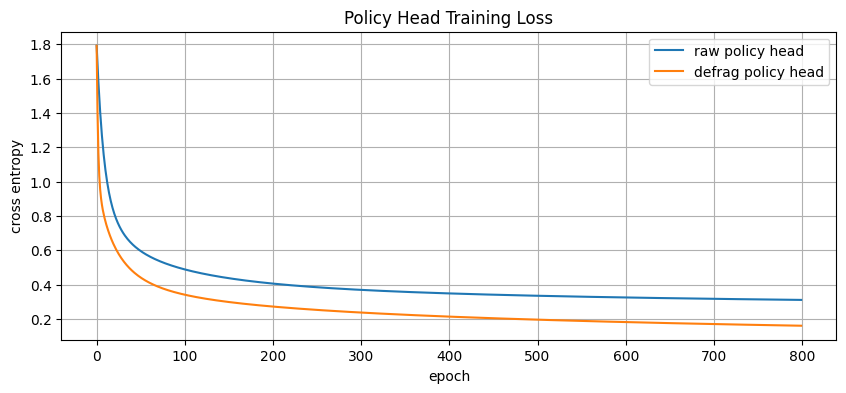

In [14]:

plt.figure(figsize=(10, 4))
plt.plot(raw_loss, label="raw policy head")
plt.plot(def_loss, label="defrag policy head")
plt.title("Policy Head Training Loss")
plt.xlabel("epoch")
plt.ylabel("cross entropy")
plt.legend()
plt.show()



## Practical readout

If defragged action prediction improves over raw action prediction,
then the next step is clear:

- keep the **shape traces**
- keep the **bridge action targets**
- stop training on final class labels
- plug a local LLM into this only as a **proposal engine**

## Real plan from here

### Local now
1. Run this notebook.
2. Check whether `defrag_policy_action_accuracy` beats `raw_policy_action_accuracy`.
3. Check whether `defrag_policy_promote_precision` is high enough to trust.
4. Expand the corruption world:
   - more packet types
   - richer shoulder cases
   - real provisional states
   - explicit missing-support growth loops

### After that
5. Replace synthetic tails with real trace packets from your runtime.
6. Train the same policy head on those traces.
7. Put a local LLM in front only after the bridge policy is stable.

### Not now
- do not pretrain a new foundation model
- do not spend pods budget on scale before the bridge policy is better than the heuristic runtime

This notebook is the defrag step.
